## **Import & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

## **Load the Data**

In [2]:
BUSINESS_DATA_PATH = 'C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\04. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data.csv'

df = pd.read_csv(BUSINESS_DATA_PATH)

print(f'Loaded {len(df):,} rows')
print(f'\nColumns ({len(df.columns)}):')
for c in df.columns:
    print(f'  - {c} ({df[c].dtype})')

df.head(10)

Loaded 3,882 rows

Columns (16):
  - Name (object)
  - Category (object)
  - Latitude (float64)
  - Longitude (float64)
  - Address (object)
  - Country (object)
  - City (object)
  - Postal Code (int64)
  - Rating (float64)
  - Reviews (float64)
  - Source (object)
  - Description (object)
  - NACE Code (float64)
  - NACE Description (EN) (object)
  - Municipal_Community (object)
  - Neighborhood (object)


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,Source,Description,NACE Code,NACE Description (EN),Municipal_Community,Neighborhood
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.76,"Retail sale of flowers, plants, seeds, fertili...",Municipal Community of Volos,Nees Pagases
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.59,"Retail sale of furniture, lighting equipment a...",Municipal Community of Volos,Aivaliotika
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,94.91,Activities of religious organisations,Municipal Community of Volos,Nees Pagases
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,49.41,Freight transport by road,Municipal Community of Volos,Nees Pagases
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Municipal Community of Volos,Nees Pagases
5,Χαλιφασ Κωνσταντινοσ Κ,Car Parts and Accessories,39.358160,22.924739,Κορωνίου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,45.32,Retail trade of motor vehicle parts and access...,Municipal Community of Volos,Neapoli
6,Μαγνησια,Newsstand,39.355263,22.925644,Λεωφόρος Αθηνών 84,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,47.62,Retail sale of newspapers and stationery in sp...,Municipal Community of Volos,Neapoli
7,4o Lukeio Volou,High School,39.359933,22.926386,Καλέργη,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,85.20,Primary education,Municipal Community of Volos,Neapoli
8,Φροντιστήριο Αγγλικών Πέπη Τόμπρα,Language School,39.360687,22.926729,Λεμεσσού,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,foursquare,NaN,85.59,Other education n.e.c.,Municipal Community of Volos,Neapoli
9,Μπαλαμωτησ,Grocery Store,39.351206,22.926013,Κεντρική Λαχαναγορά Βόλος,Greece,Βόλος Μαγνησίας,38500,NaN,NaN,foursquare,NaN,47.11,Retail sale in non-specialised stores with foo...,Municipal Community of Volos,Aivaliotika


In [3]:
NACE_COL = 'NACE Code'
NEIGHBORHOOD_COL = 'Neighborhood'

## **Null Analysis**

In [4]:
# Null Analysis
print('Null counts per column:')
print(df.isnull().sum().sort_values(ascending=False))

print(f'\nRows with null {NACE_COL}: {df[NACE_COL].isnull().sum()}')
print(f'Rows with null {NEIGHBORHOOD_COL}: {df[NEIGHBORHOOD_COL].isnull().sum()}')
print(f'Rows with both non-null: {df[[NACE_COL, NEIGHBORHOOD_COL]].dropna().shape[0]}')

# For the rest of the analysis, drop rows missing either field
df_clean = df.dropna(subset=[NACE_COL, NEIGHBORHOOD_COL]).copy()
print(f'\nUsable rows after dropping nulls: {len(df_clean):,} '
      f'(dropped {len(df) - len(df_clean):,})')

Null counts per column:
Description              3691
Reviews                  3676
Rating                   3654
Name                        0
Category                    0
Latitude                    0
Longitude                   0
Address                     0
Country                     0
City                        0
Postal Code                 0
Source                      0
NACE Code                   0
NACE Description (EN)       0
Municipal_Community         0
Neighborhood                0
dtype: int64

Rows with null NACE Code: 0
Rows with null Neighborhood: 0
Rows with both non-null: 3882

Usable rows after dropping nulls: 3,882 (dropped 0)


## **NACE Class Distribution**

In [7]:
nace_counts = df_clean[NACE_COL].value_counts()

print(f'Unique NACE classes present: {len(nace_counts)}')
print(f'  (out of 306 total in NACE taxonomy)')
print(f'\nBusinesses per NACE class — summary:')
print(nace_counts.describe())

print(f'\nTop 15 NACE classes by business count:')
print(nace_counts.head(15))

print(f'\nDistribution buckets:')
print(f'  NACE classes with 1 business:    {(nace_counts == 1).sum()}')
print(f'  NACE classes with 2-5 businesses: {((nace_counts >= 2) & (nace_counts <= 5)).sum()}')
print(f'  NACE classes with 6-20:           {((nace_counts >= 6) & (nace_counts <= 20)).sum()}')
print(f'  NACE classes with 21-100:         {((nace_counts >= 21) & (nace_counts <= 100)).sum()}')
print(f'  NACE classes with >100:           {(nace_counts > 100).sum()}')

Unique NACE classes present: 306
  (out of 306 total in NACE taxonomy)

Businesses per NACE class — summary:
count    306.000000
mean      12.686275
std       22.749086
min        1.000000
25%        2.000000
50%        5.500000
75%       13.750000
max      200.000000
Name: count, dtype: float64

Top 15 NACE classes by business count:
NACE Code
86.22    200
56.10    194
86.90    146
56.30    100
85.59     92
47.59     86
47.71     76
69.20     66
45.20     63
69.10     60
47.78     59
43.22     58
86.23     56
84.11     54
96.02     53
Name: count, dtype: int64

Distribution buckets:
  NACE classes with 1 business:    56
  NACE classes with 2-5 businesses: 97
  NACE classes with 6-20:           106
  NACE classes with 21-100:         44
  NACE classes with >100:           3


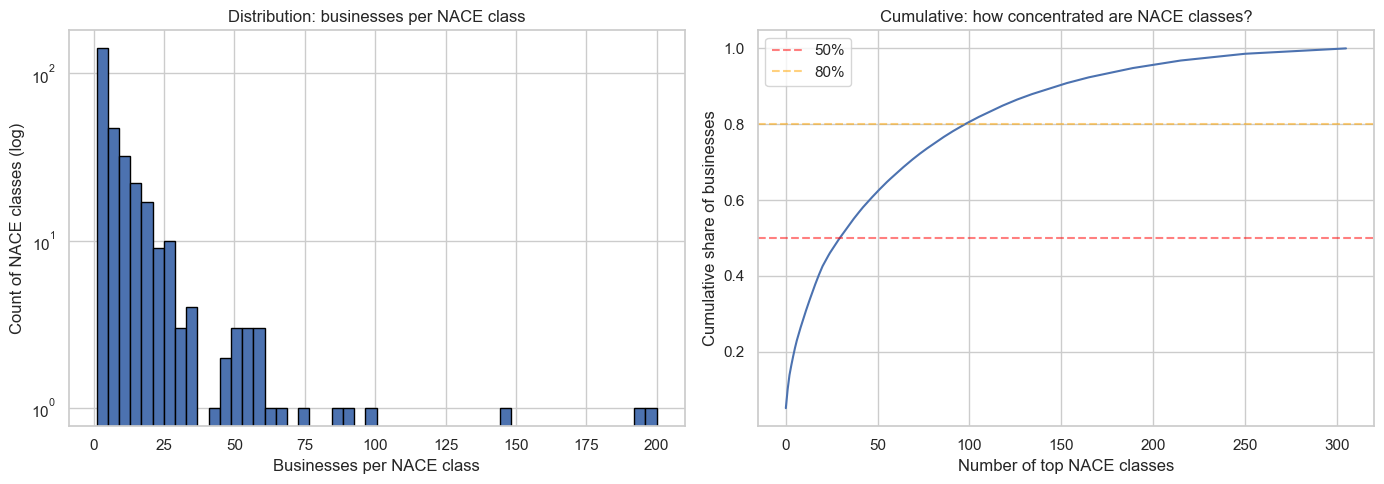

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of businesses per NACE class (log y)
axes[0].hist(nace_counts.values, bins=50, edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('Businesses per NACE class')
axes[0].set_ylabel('Count of NACE classes (log)')
axes[0].set_title('Distribution: businesses per NACE class')

# Right: Cumulative share of businesses by NACE class
cum_share_nace = np.cumsum(nace_counts.values) / nace_counts.sum()
axes[1].plot(range(len(cum_share_nace)), cum_share_nace)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].axhline(0.8, color='orange', linestyle='--', alpha=0.5, label='80%')
axes[1].set_xlabel('Number of top NACE classes')
axes[1].set_ylabel('Cumulative share of businesses')
axes[1].set_title('Cumulative: how concentrated are NACE classes?')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/nace_distribution_analysis.png', dpi=100, bbox_inches='tight')

## **Neighborhood Distribution**

In [6]:
nbhd_counts = df_clean[NEIGHBORHOOD_COL].value_counts()

print(f'Unique neighbourhoods in data: {len(nbhd_counts)} (expected: 48)')
print(f'\nBusinesses per neighbourhood — summary:')
print(nbhd_counts.describe())

print(f'\nAll neighbourhoods, sorted by business count:')
print(nbhd_counts.to_string())

Unique neighbourhoods in data: 39 (expected: 48)

Businesses per neighbourhood — summary:
count     39.000000
mean      99.538462
std      147.965829
min        1.000000
25%        4.000000
50%       37.000000
75%      124.500000
max      551.000000
Name: count, dtype: float64

All neighbourhoods, sorted by business count:
Neighborhood
Agios Nikolaos              551
Metamorfosi                 522
Nea Ionia                   490
Analipsi                    380
Epta Platania - Oksigono    220
Neapoli                     187
Agios Vasilios              182
Agioi Anargiroi             179
Palaia                      154
Agios Konstantinos          139
Agia Paraskeui              110
Dimitriada                  109
Agios Georgios               92
Karagats                     88
Nea Dimitriada               83
Asteria Agrias               81
Hiliadou                     73
Nees Pagases                 46
Dimini                       40
Aivaliotika                  37
Agia Kyriaki          

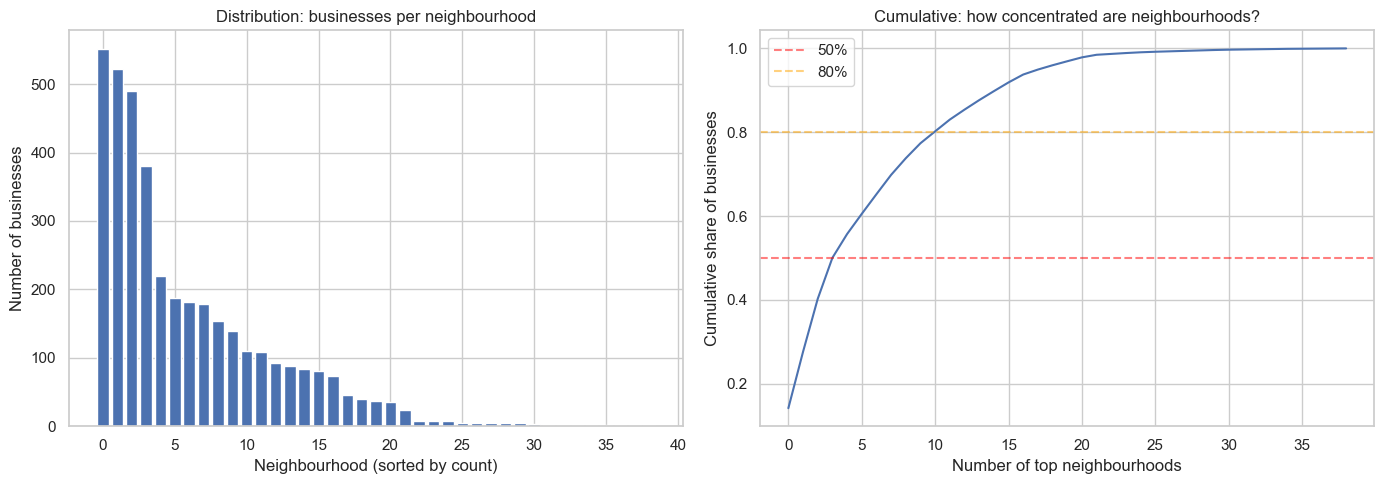

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of businesses per neighbourhood
axes[0].bar(range(len(nbhd_counts)), nbhd_counts.values)
axes[0].set_xlabel('Neighbourhood (sorted by count)')
axes[0].set_ylabel('Number of businesses')
axes[0].set_title('Distribution: businesses per neighbourhood')

# Right: Cumulative share of businesses by neighbourhood
cum_share_nbhd = np.cumsum(nbhd_counts.values) / nbhd_counts.sum()
axes[1].plot(range(len(cum_share_nbhd)), cum_share_nbhd)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1].axhline(0.8, color='orange', linestyle='--', alpha=0.5, label='80%')
axes[1].set_xlabel('Number of top neighbourhoods')
axes[1].set_ylabel('Cumulative share of businesses')
axes[1].set_title('Cumulative: how concentrated are neighbourhoods?')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/neighbourhood_distribution_analysis.png', dpi=100, bbox_inches='tight')

Of the 48 neighbourhoods, 9 have zero business records and are unreachable by pure CF baselines, illustrating a structural limitation that content-aware LLM methods can address.

## **Joint Distribution**

In [7]:
n_nace = df_clean[NACE_COL].nunique()
n_nbhd = 48  # Total neighbourhoods, including ones with zero businesses

# Count distinct (NACE, neighborhood) pairs with at least one business
pairs = df_clean[[NACE_COL, NEIGHBORHOOD_COL]].drop_duplicates()
n_pairs = len(pairs)

total_cells = n_nace * n_nbhd
density = n_pairs / total_cells

print(f'Matrix shape (with all 48 neighbourhoods): {n_nace} × {n_nbhd}')
print(f'Total cells: {total_cells:,}')
print(f'Non-zero cells: {n_pairs:,}')
print(f'Density: {density:.2%}')
print(f'Sparsity: {1 - density:.2%}')

# Distribution of cell values (when non-zero)
cell_counts = df_clean.groupby([NACE_COL, NEIGHBORHOOD_COL]).size()
print(f'\nNon-zero cell values — summary:')
print(cell_counts.describe())
print(f'\nDistribution of cell counts:')
print(f'  Cells with value 1:    {(cell_counts == 1).sum()}')
print(f'  Cells with value 2-5:   {((cell_counts >= 2) & (cell_counts <= 5)).sum()}')
print(f'  Cells with value 6-20:  {((cell_counts >= 6) & (cell_counts <= 20)).sum()}')
print(f'  Cells with value >20:   {(cell_counts > 20).sum()}')

Matrix shape (with all 48 neighbourhoods): 306 × 48
Total cells: 14,688
Non-zero cells: 1,702
Density: 11.59%
Sparsity: 88.41%

Non-zero cell values — summary:
count    1702.000000
mean        2.280846
std         3.528648
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        67.000000
dtype: float64

Distribution of cell counts:
  Cells with value 1:    1014
  Cells with value 2-5:   573
  Cells with value 6-20:  103
  Cells with value >20:   12


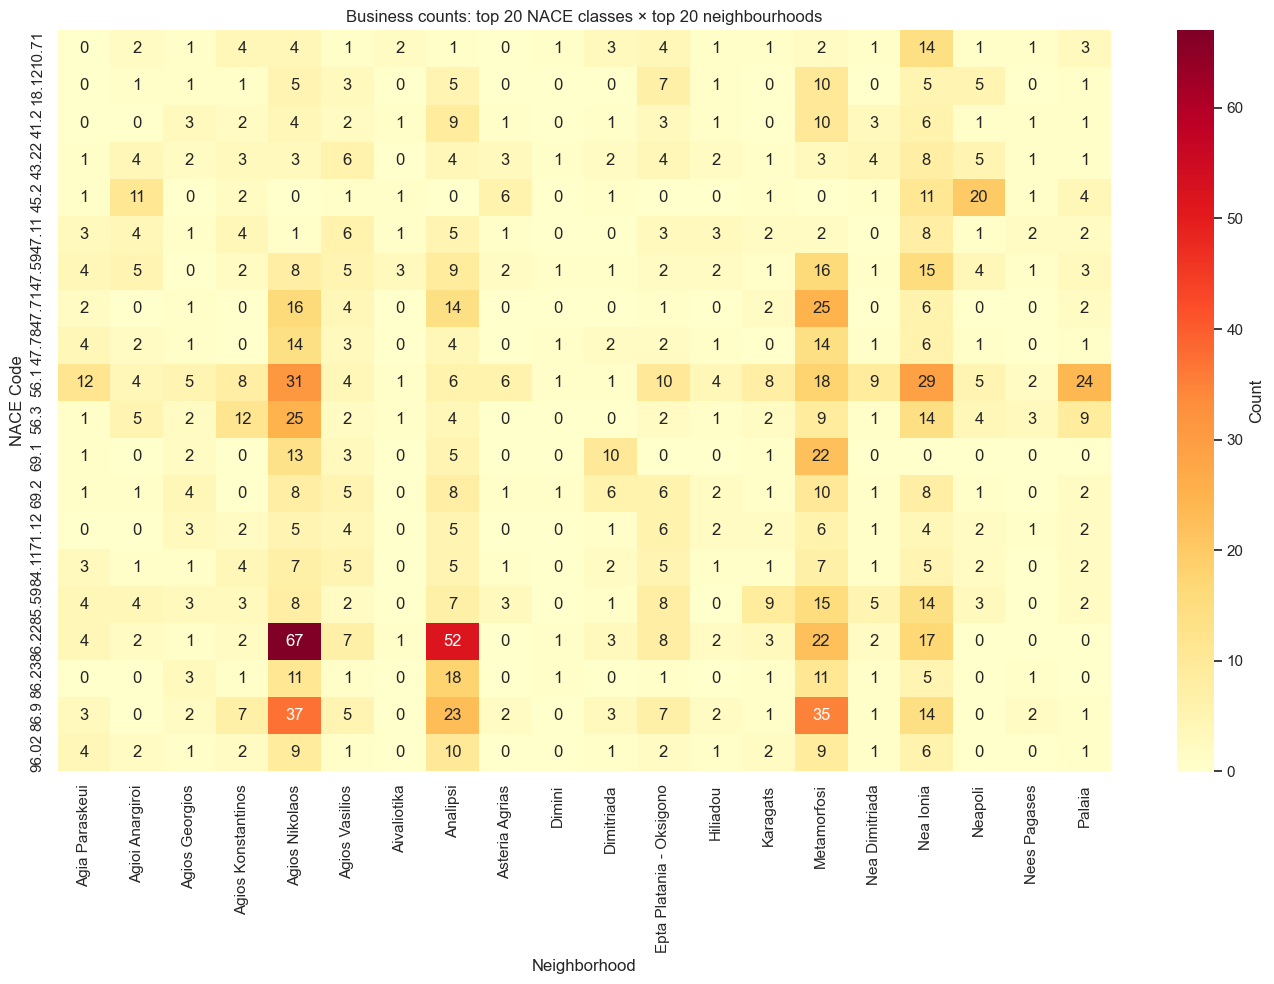

In [13]:
top_nace = nace_counts.head(20).index
top_nbhd = nbhd_counts.head(20).index

heatmap_data = (
    df_clean[
        df_clean[NACE_COL].isin(top_nace) & 
        df_clean[NEIGHBORHOOD_COL].isin(top_nbhd)
    ]
    .groupby([NACE_COL, NEIGHBORHOOD_COL])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Business counts: top 20 NACE classes × top 20 neighbourhoods')
plt.tight_layout()
plt.savefig('../results/data_exploration_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()